## Load library

In [ ]:
library(CellChat)
library(NeuronChat)
library(patchwork)
library(scater)
library(Seurat)
library(tidyverse)
library(cowplot)
library(edgeR)
library(Matrix)
library(reshape2)
library(S4Vectors)
library(SingleCellExperiment)
library(pheatmap)
library(png)
library(RColorBrewer)
library(limma)
library(magrittr)
library(gridExtra)
library(knitr)
library(limma)
options(stringsAsFactors = FALSE)
library(EnhancedVolcano)
library(grid)

Loading required package: dplyr


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Loading required package: igraph


Attaching package: 'igraph'


The following objects are masked from 'package:dplyr':

    as_data_frame, groups, union


The following objects are masked from 'package:stats':

    decompose, spectrum


The following object is masked from 'package:base':

    union


Loading required package: ggplot2

Warning message:
"package 'ggplot2' was built under R version 4.3.3"
Warning message:
"replacing previous import 'data.table::dcast' by 'reshape2::dcast' when loading 'NeuronChat'"
Warning message:
"replacing previous import 'data.table::melt' by 'reshape2::melt' when loading 'NeuronChat'"
Loading required package: SingleCellExperiment

Loading required package: SummarizedExperiment

Loading required package: MatrixGenerics


## Read rds file from seurat export

In [ ]:
neuronchat_R306C <- readRDS("data_Export/R306C_2condition.rds")

## Create seurat object and split by demultiplexing indentity

In [ ]:

seurat <- SplitObject(neuronchat_R306C, split.by = "orig.ident")
NC1_counts <- seurat$S1[["RNA"]]$data
NC2_counts <- seurat$S2[["RNA"]]$data
NC1_metadata<- seurat$S1@meta.data
NC2_metadata<- seurat$S2@meta.data
nc1<-as.data.frame(NC1_counts)
q<-subset(nc1,(rowSums(sign(nc1)<0)>0) & (rowSums(sign(nc1)>0)>0)) 

In [6]:
nc1['MECP2', ]

,S1_AAACCCAAGAGATTCA-1,S1_AAACCCAAGTCATACC-1,S1_AAACCCACAGCGTACC-1,S1_AAACCCACATATGGCT-1,S1_AAACCCAGTCATCGCG-1,S1_AAACCCATCCGATTAG-1,S1_AAACGAATCACAATGC-1,S1_AAACGAATCTACGGGC-1,S1_AAACGCTAGTTCTACG-1,S1_AAACGCTCAATACCCA-1,⋯,S1_TTTGGTTGTCAAGTTC-1,S1_TTTGGTTGTTTAAGGA-1,S1_TTTGGTTTCGGCTGGT-1,S1_TTTGGTTTCTGTCCCA-1,S1_TTTGTTGAGCACTGGA-1,S1_TTTGTTGAGGTCACAG-1,S1_TTTGTTGCAAGGTACG-1,S1_TTTGTTGGTAGGAGGG-1,S1_TTTGTTGTCTCATTGT-1,S1_TTTGTTGTCTCGAGTA-1
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
MECP2,0,0,0,0,0,0,0,1.306504,0.8114862,1.48402,⋯,1.397384,1.616839,0.7284233,2.021387,1.435694,0,1.848865,0.4629069,0,0


## Create neuornchat object as seprated condition

In [ ]:
NC1 <- createNeuronChat(NC1_counts, DB='human', meta= NC1_metadata, group.by =NC1_metadata$deep_cell_type.ident)
NC2 <- createNeuronChat(NC2_counts, DB='human', meta= NC2_metadata, group.by =NC2_metadata$deep_cell_type.ident) 


Create a NeuronChat object from a data matrix



Create a NeuronChat object from a data matrix



## Compute neuronchat interaction

In [ ]:


NC1 <- run_NeuronChat(NC1,M=100)
NC2 <- run_NeuronChat(NC2,M=100)

net_aggregated_NC1_weight <- net_aggregation(NC1@net,method = 'weight') 
net_aggregated_NC1_count  <- net_aggregation(NC1@net,method = 'count')  
net_aggregated_NC2_weight <- net_aggregation(NC2@net,method = 'weight') 
net_aggregated_NC2_count  <- net_aggregation(NC2@net,method = 'count')  
names(NC1@net)
names(NC2@net)


Time difference of 1.410101 mins
Time difference of 57.16953 secs


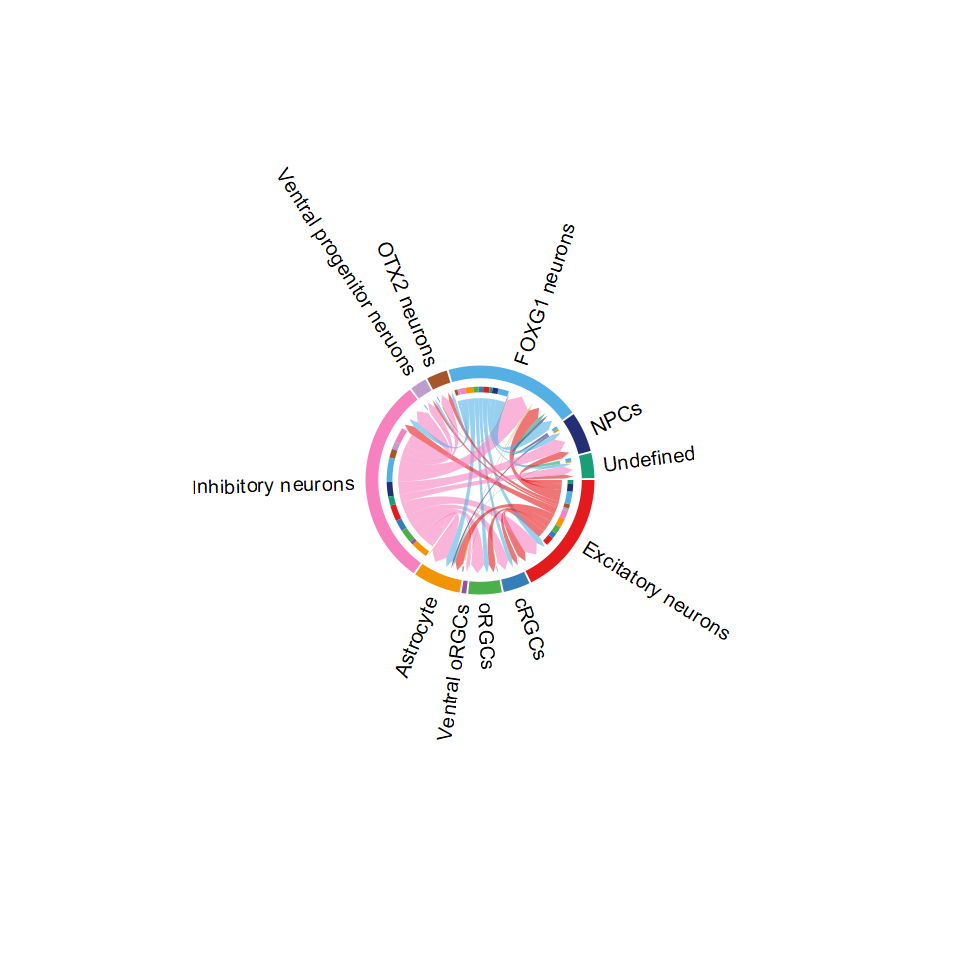

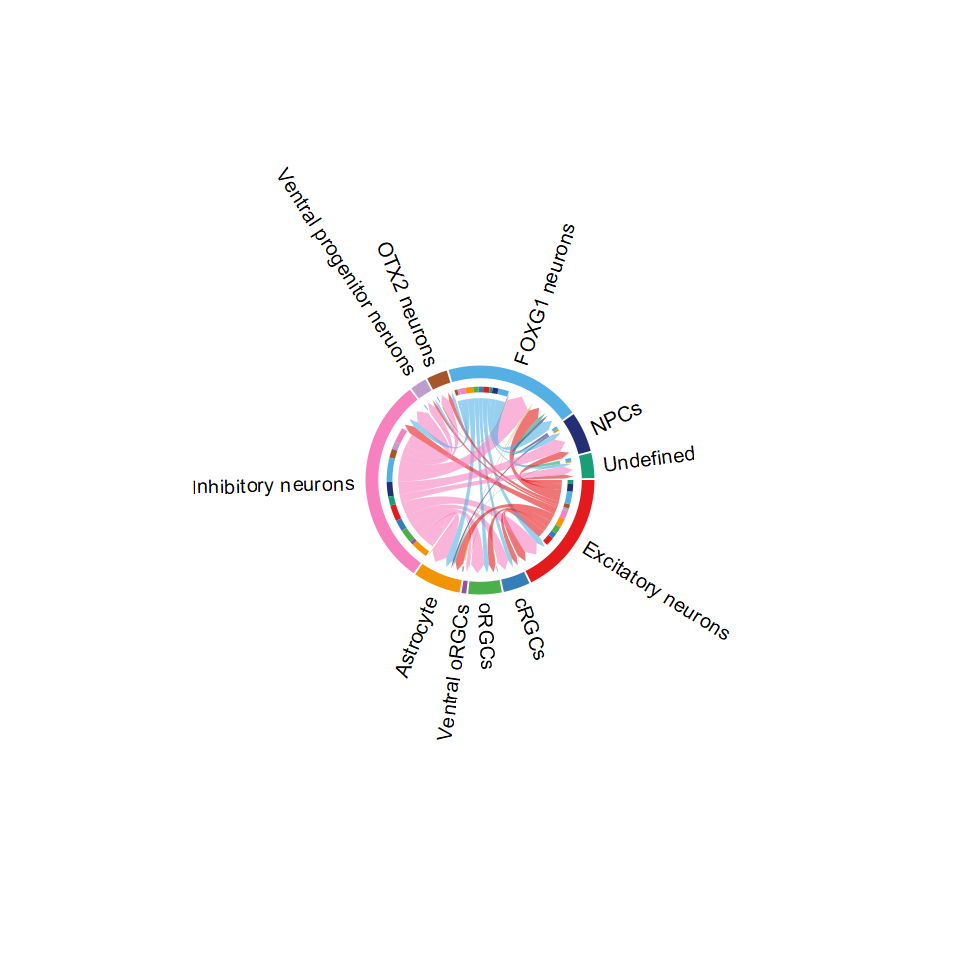

In [ ]:
p1<-netVisual_chord_neuron(NC1,method = 'weight',lab.cex = 1)
p1


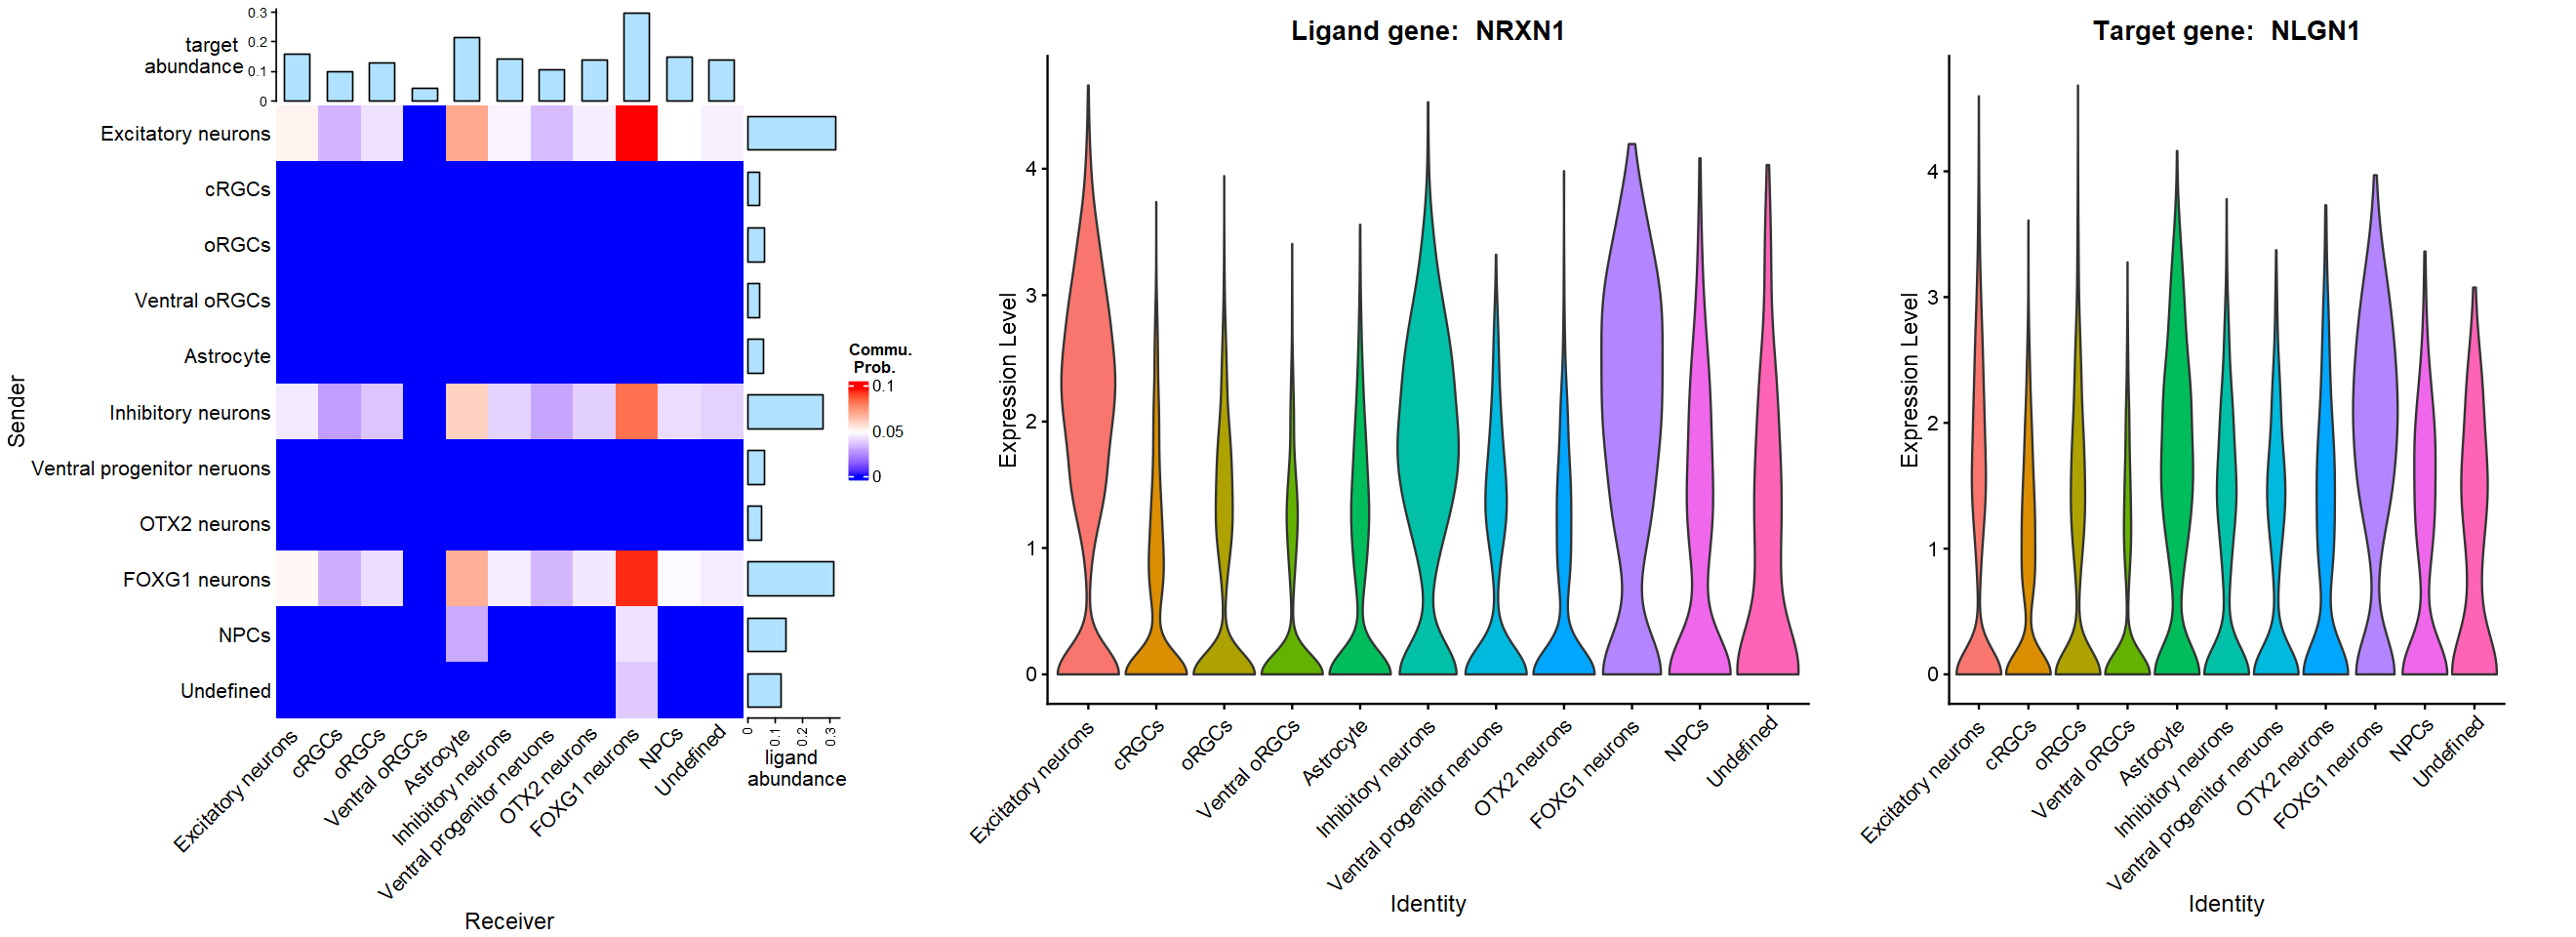

In [15]:
options(repr.plot.width=22, repr.plot.height=8)
lig_tar_heatmap(NC1,interaction_name='NRXN1_NLGN1',width.vector=c(0.38,0.35,0.27))

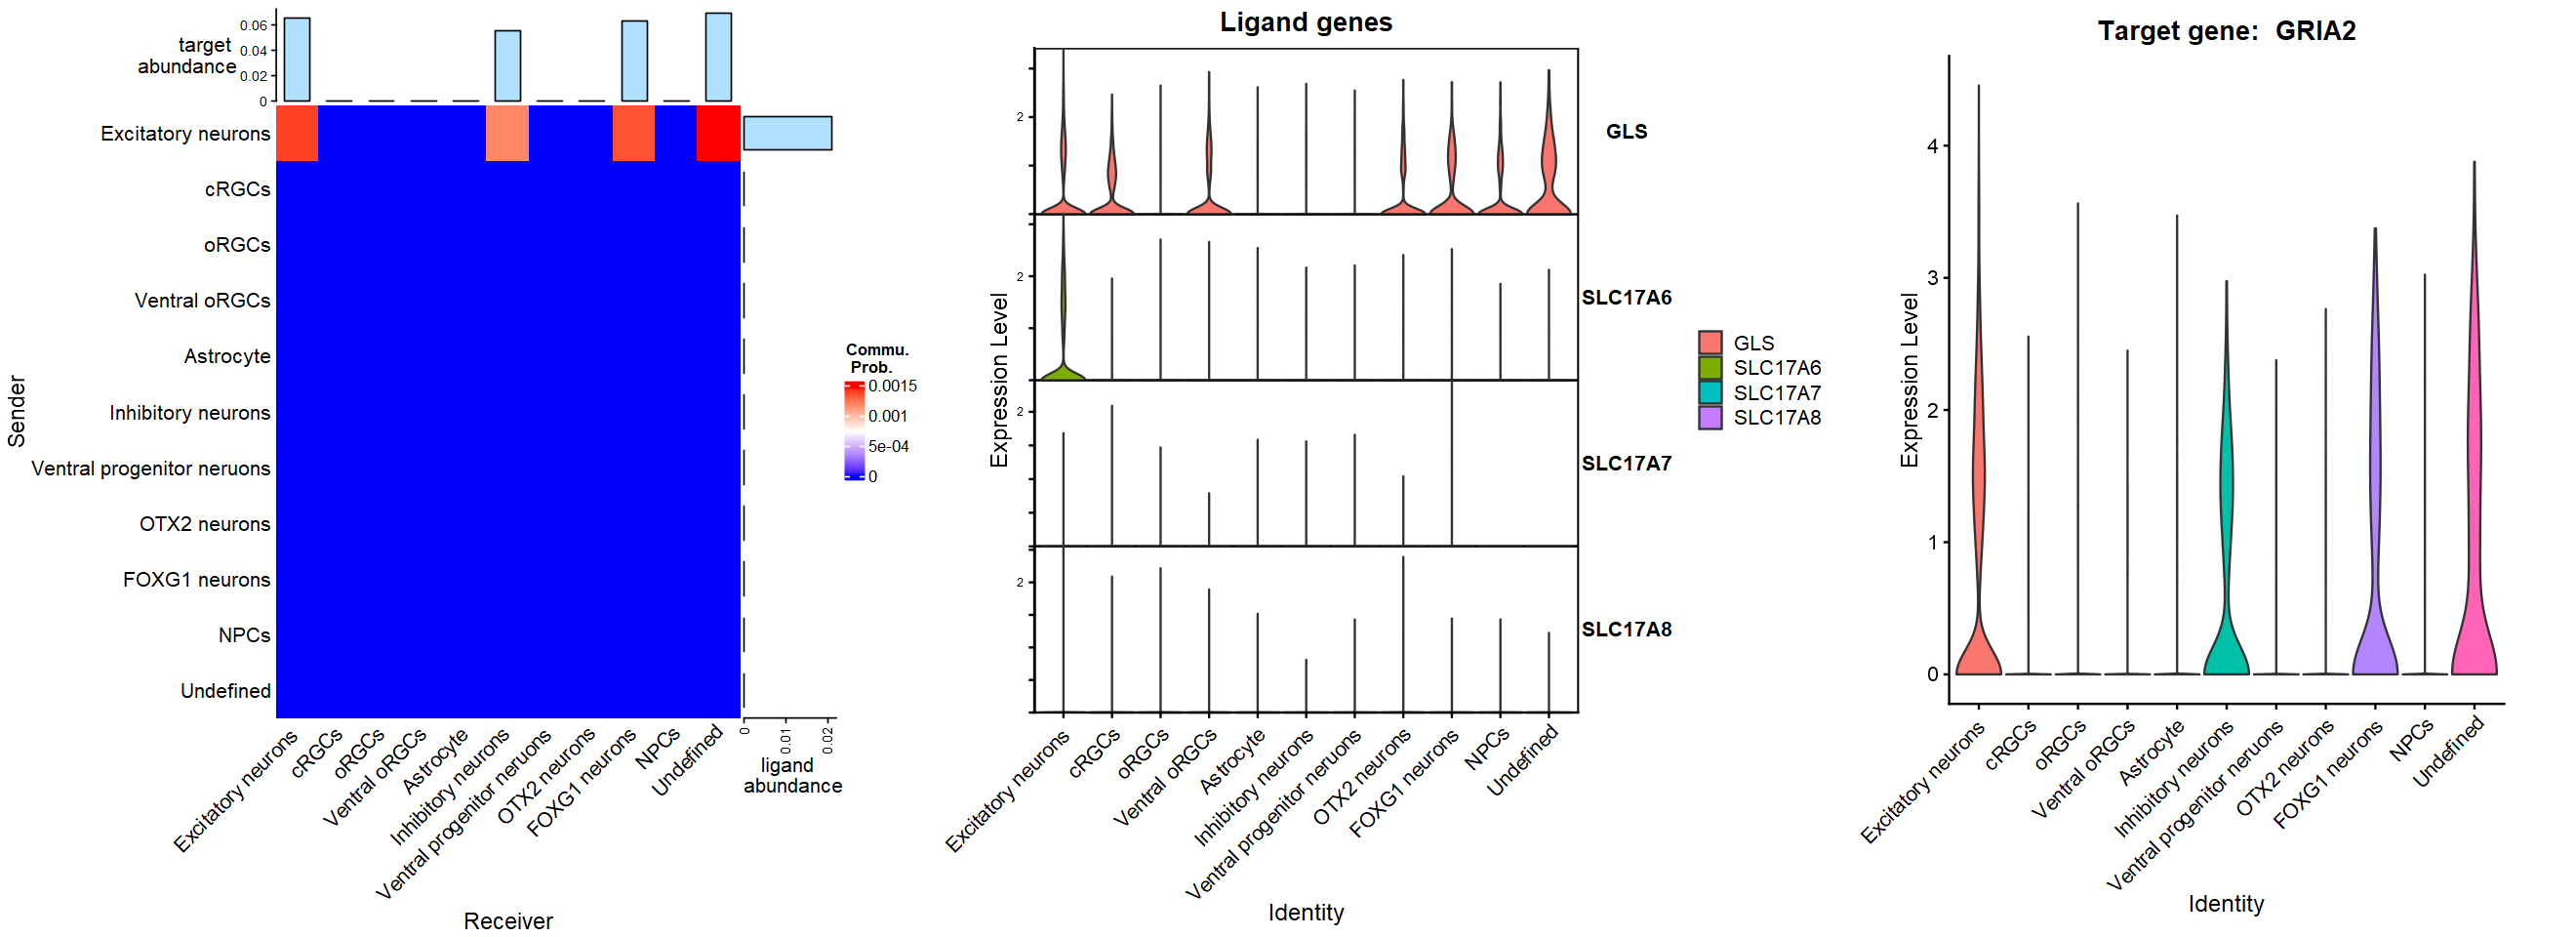

In [16]:
options(repr.plot.width=22, repr.plot.height=8)
lig_tar_heatmap(NC2,interaction_name='Glu_GRIA2',width.vector=c(0.38,0.35,0.27))

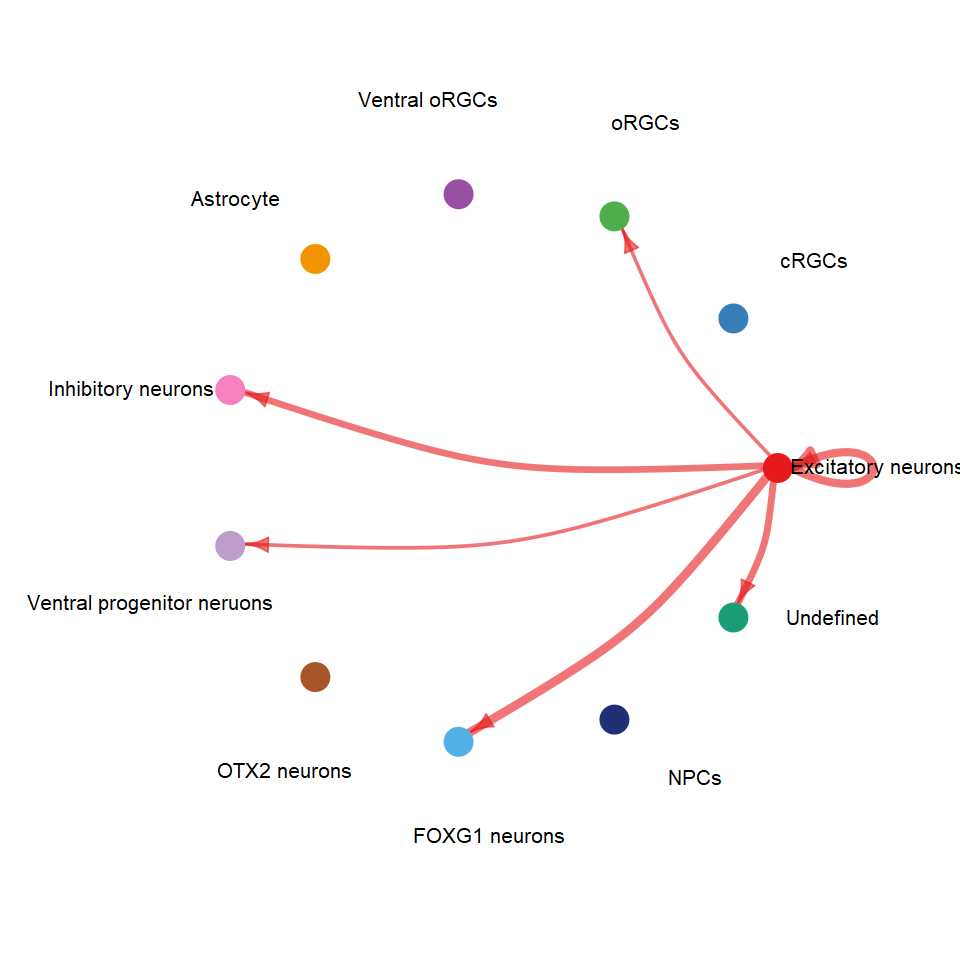

In [ ]:
#par(mfrow=c(1,2))
# Visualization for the single interaction pair, circle plot
options(repr.plot.width=8, repr.plot.height=8)
p1<-netVisual_circle_neuron(NC1@net$Glu_GRIA2,vertex.label.cex = 1)   


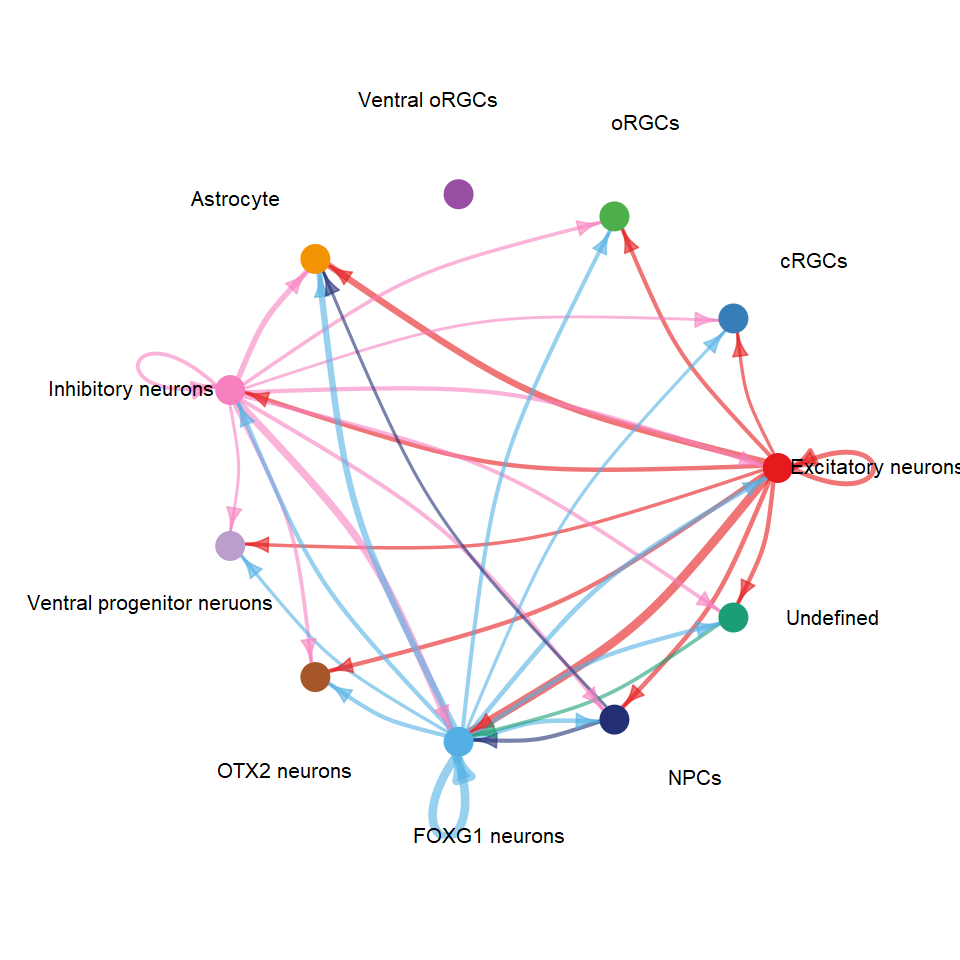

In [ ]:
options(repr.plot.width=8, repr.plot.height=8)
p1<-netVisual_circle_neuron(NC1@net$NRXN1_NLGN1,vertex.label.cex = 1)   


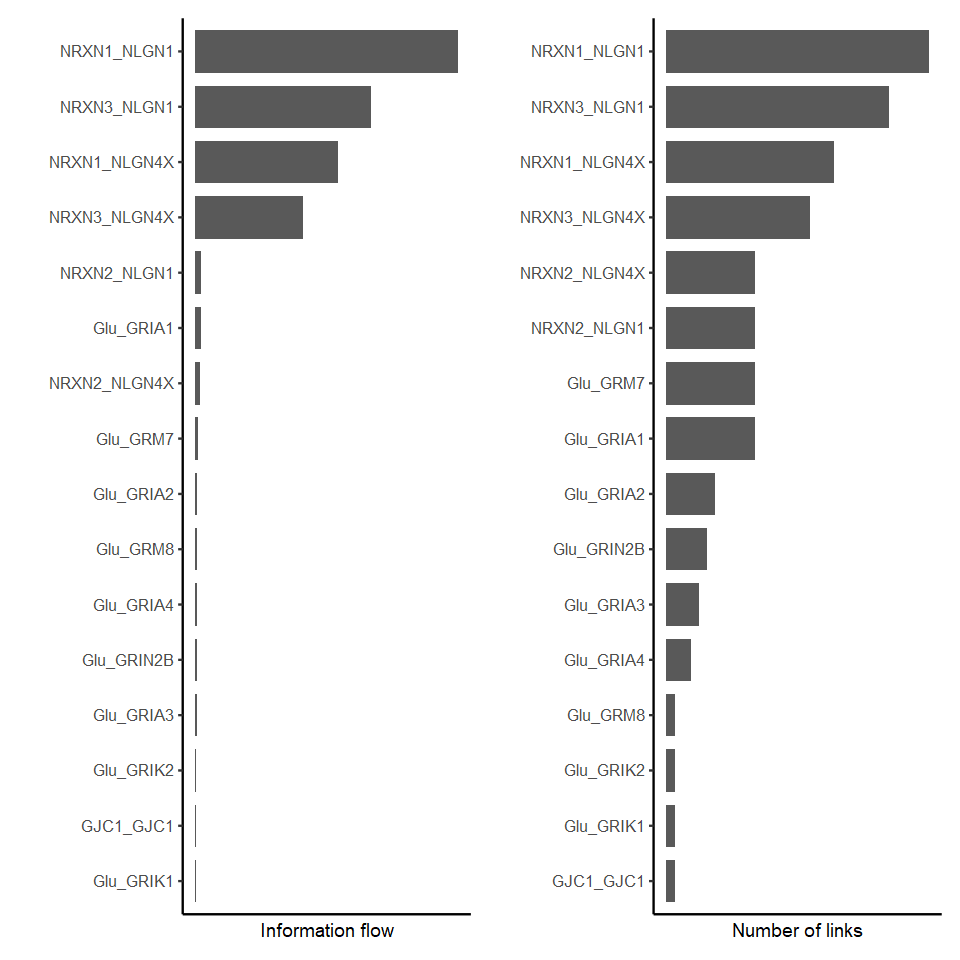

In [ ]:
g1 <- rankNet_Neuron(NC1,slot.name = "net",measure = c("weight"),mode='single',font.size = 5) 
g2 <- rankNet_Neuron(NC1,slot.name = "net",measure = c("count"), mode='single',font.size = 5)
g1+g2
selectK_Neuron(NC1,pattern = "outgoing")
selectK_Neuron(NC1,pattern = "incoming")

selectK_Neuron(NC2,pattern = "outgoing")
selectK_Neuron(NC2,pattern = "incoming")


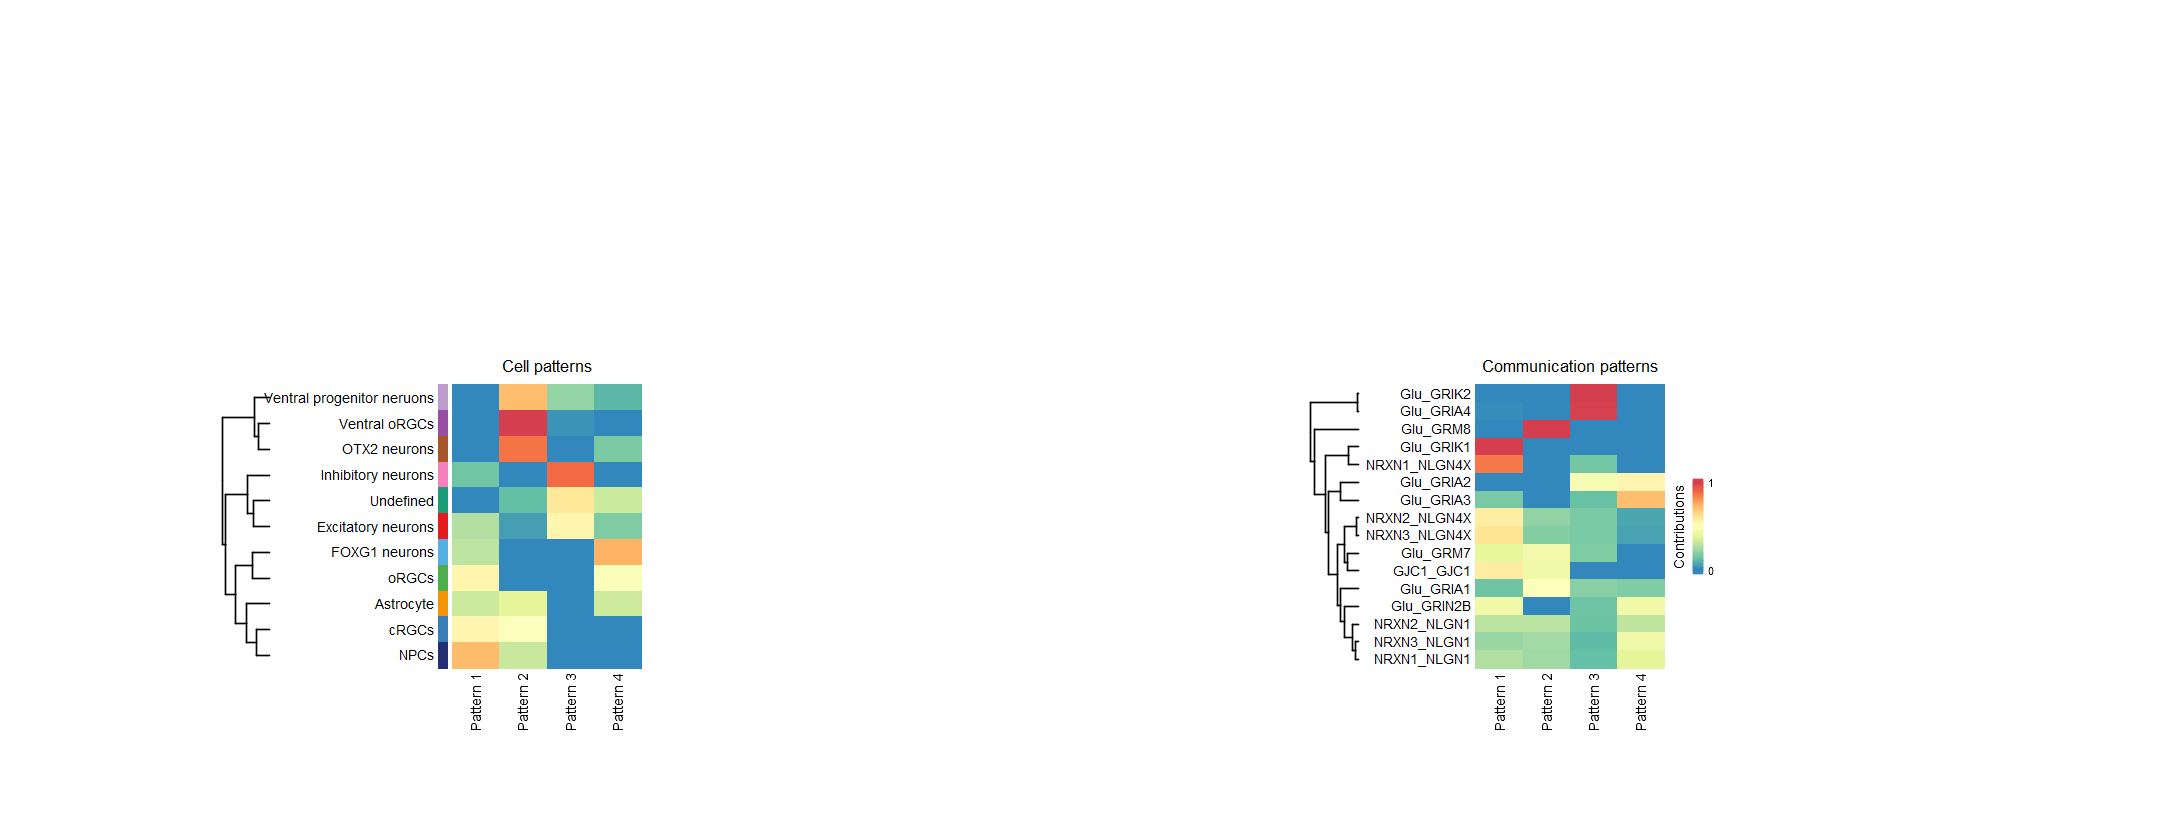

In [ ]:
options(repr.plot.width=18, repr.plot.height=7)
x<- identifyCommunicationPatterns_Neuron(NC1, slot.name = "net", pattern = c("outgoing"), k=4,height = 6)
x<- identifyCommunicationPatterns_Neuron(NC1, slot.name = "net", pattern = c("incoming"), k=4,height = 6)

In [ ]:
library(ggalluvial)
netAnalysis_river_Neuron(NC1, slot.name="net", pattern = c("outgoing"), font.size = 2.5, cutoff.1 = 0.5, cutoff.2=0.5)

Please make sure you have load `library(ggalluvial)` when running this function



ERROR: Error in seq.default(1, nPatterns * 2, by = 2): wrong sign in 'by' argument


## Differential analysis

In [21]:
list <-list(NC1,NC2)
neuronchat_list <- mergeNeuronChat(list, add.names = names(list))


Merge the following slots: 'data.signaling','net', 'netP','meta', 'idents', 'var.features' , 'DB', and 'LR'.



In [22]:
neuronchat_list <- computeNetSimilarityPairwise_Neuron(neuronchat_list, slot.name = "net", type = "functional",comparison = NULL)
neuronchat_list <- netEmbedding(neuronchat_list,slot.name = "net_analysis", type = "functional",comparison =NULL)
neuronchat_list <- netClustering(neuronchat_list, slot.name = "net_analysis", type = "functional",comparison = NULL)

Compute signaling network similarity for datasets 1 2 
Manifold learning of the signaling networks for datasets 1 2 
Classification learning of the signaling networks for datasets 1 2 


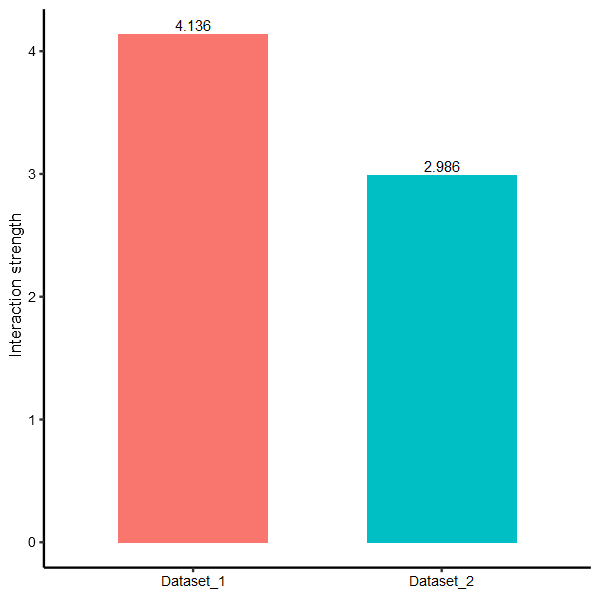

In [ ]:
options(repr.plot.width=5, repr.plot.height=5)
p1 <- compareInteractions_Neuron(neuronchat_list,measure = c("weight"),comparison = c(1,2),group=c(1,2),show.legend = F)
p2 <- compareInteractions_Neuron(neuronchat_list,measure = c("count"),comparison = c(1,2),group=c(1,2),show.legend = F )
p1


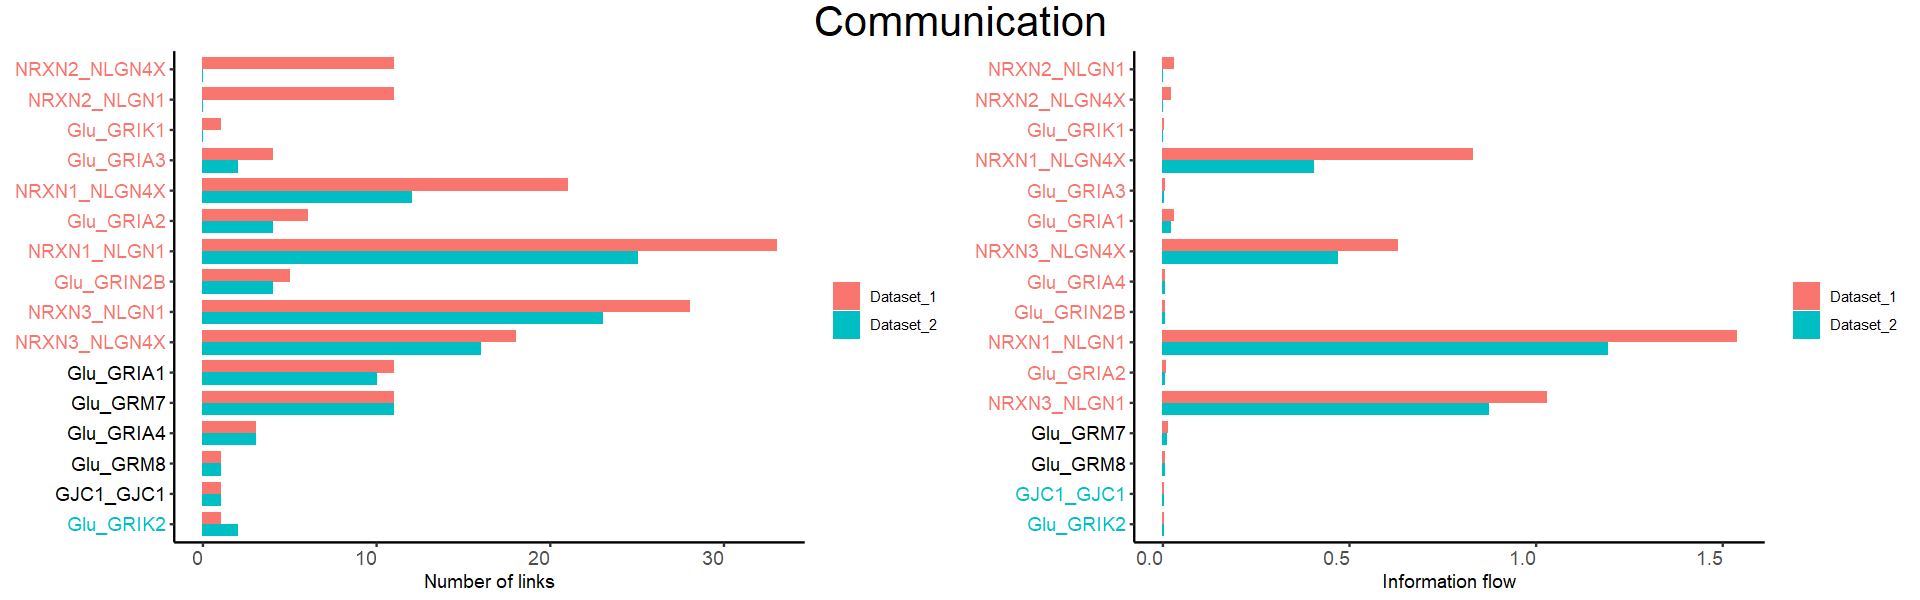

In [27]:
# communication for individual interaction pairs
options(repr.plot.width=16, repr.plot.height=5)

g1 <- rankNet_Neuron(neuronchat_list,mode='comparison',measure = c("count"),comparison = 1:2,do.stat = F,tol = 0.1,stacked = F,font.size = 11)
g2 <- rankNet_Neuron(neuronchat_list,mode='comparison',measure = c("weight"),comparison = 1:2,do.stat = F,tol = 0.1,stacked = F,font.size = 11) 
gg <- grid.arrange(g1, g2,
        ncol = 2,
        nrow = 1,
        top = textGrob("Communication",
        gp = gpar(fontsize = 25)))

ggplot2::ggsave(filename = "Figures/neuronchat_R306C/comparison_interaction_all.pdf", 
                plot = gg, 
                device = "pdf", 
                dpi = 600, 
                width = 200,
                height = 100,
                units = "mm")